### Parameter calibration at present-day equilibrium

We calibrate the model so that the present-day ice sheet height $h_0 = 3000 \,\mathrm{m}$ is an equilibrium solution when there is no additional warming ($\Delta T = 0$). The value of $h_0$ is chosen to be representative of large ice sheet thickness.

Writing the model as
$$
\frac{dh}{dt} = P - \frac{r (T_0 - T_m)^2}{h} - Fh,
$$
define
$$
A_0 := T_0 - T_m \geq 0,
$$
so that the melt term is active at $\Delta T = 0$. Parameters $r$ and $F$ are chosen to be small and of comparable magnitude, ensuring realistic mass balance behaviour.

Imposing the equilibrium condition $\frac{dh}{dt} = 0$ at $h = h_0$ gives
$$
P = \left(F + r A_0^2 \right) h_0.
$$

We fix $r$, $F$, and $A_0$, and compute $P$ accordingly so that $h_0$ is a steady state of the system.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# present-day reference height
h0 = 3000.0

# choose parameters so the melt term is active at DeltaT = 0
A0 = 1.0          # = T0 - Tm, must be >= 0 in this model
r = 1e-4
F = 2e-4

# calibrate precipitation so h0 is equilibrium at DeltaT = 0
P = (F + r*A0**2) * h0

print("P =", P)
print("Check equilibrium at h0:", P - (F + r*A0**2)*h0)

P = 0.9000000000000001
Check equilibrium at h0: 0.0


### Temperature forcing and model dynamics

We represent warming through a scenario-dependent shift in the melt factor
$$
A = T_0 + \Delta T - T_m.
$$

Rather than modelling $\Delta T(t)$ explicitly, we consider discrete scenarios:
- **baseline**: $A = A_0$
- **low warming**: $A = A_0 + 0.5$
- **high warming**: $A = A_0 + 1.5$

Substituting into the model gives the autonomous system
$$
\frac{dh}{dt} = P - \left(F + rA^2 \right) h,
$$
where increased warming (larger $A$) enhances the effective mass-loss rate.

This formulation isolates the impact of temperature on ice sheet stability while keeping the model analytically tractable.

In [3]:
def melt_factor(scenario):
    if scenario == "low":
        return A0 + 0.5
    elif scenario == "high":
        return A0 + 1.5
    else:
        return A0
    
def dhdt_base(t, h, scenario):  # t included for compatibility with solve_ivp (autonomous system)
    A = melt_factor(scenario)
    return P - (F + r*A**2) * h

In [4]:
t_span = (0, 2000) # long-term integration horizon
t_eval = np.linspace(*t_span, 1000)

def simulate(scenario): # numerically integrates the base model for a given warming scenario
    sol = solve_ivp(
        lambda t, h: dhdt_base(t, h, scenario),
        t_span,
        [h0],
        t_eval=t_eval
    )
    return sol.t, sol.y[0]

In [5]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

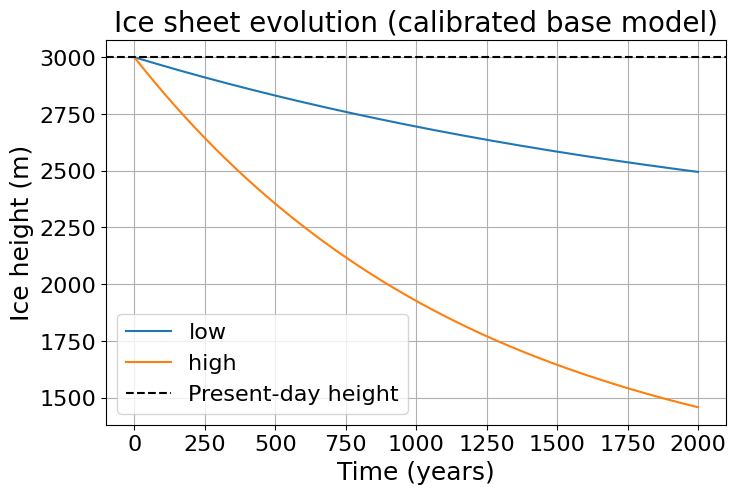

In [6]:
plt.figure(figsize=(8,5))

for scenario in ["low", "high"]:
    t, h = simulate(scenario)
    plt.plot(t, h, label=scenario)

plt.axhline(h0, linestyle='--', color='black', label='Present-day height')
plt.xlabel("Time (years)")
plt.ylabel("Ice height (m)")
plt.title("Ice sheet evolution (calibrated base model)")
plt.legend()
plt.grid()
plt.show()

### Equilibrium structure under warming

We examine the equilibria by plotting $\frac{dh}{dt}$ as a function of ice height $h$ for different values of the melt factor $A$.

Equilibria occur where $\frac{dh}{dt} = 0$. As $A$ increases (stronger warming), the lines shift downward, reducing the equilibrium ice height
$$
h^* = \frac{P}{F + rA^2}.
$$

This shows that increased temperature leads to lower steady-state ice levels, with sufficiently large warming driving the system towards much smaller equilibria.

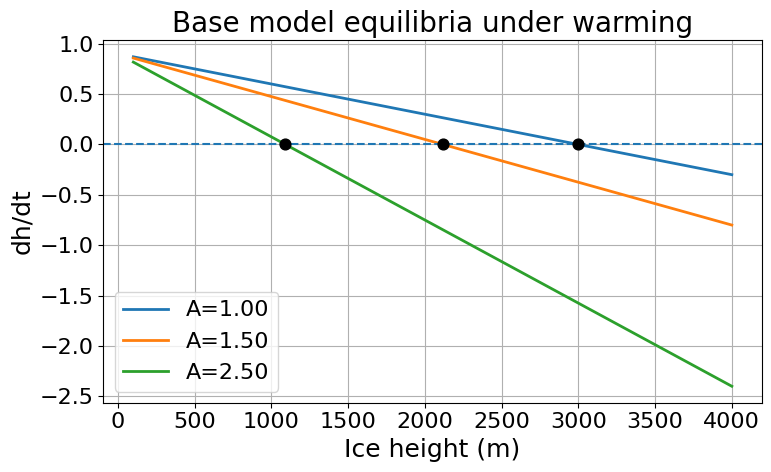

In [7]:
h_vals = np.linspace(100, 4000, 500)

plt.figure(figsize=(8,5))

for A in [A0, A0+0.5, A0+1.5]:
    dh_vals = [P - (F + r*A**2)*h for h in h_vals]
    plt.plot(h_vals, dh_vals, label=f"A={A:.2f}", linewidth=2)

for A in [A0, A0+0.5, A0+1.5]:
    h_eq = P / (F + r*A**2)
    plt.scatter(h_eq, 0, color='black', s=60, zorder=5)

plt.axhline(0, linestyle='--', linewidth=1.5)

# BIG fonts
plt.xlabel("Ice height (m)", fontsize=18)
plt.ylabel("dh/dt", fontsize=18)
plt.title("Base model equilibria under warming", fontsize=20)

plt.legend(fontsize=16)

# Big tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid()
plt.tight_layout()
plt.savefig("base-eq.pdf", bbox_inches="tight")
plt.show()

### Extended model parameters

The extended model introduces melt sensitivity ($\mu$), a characteristic height scale ($h_c$), and nonlinear flow parameters ($k, n$). Values are chosen to be physically reasonable and to produce meaningful nonlinear behaviour.

- $h_c = 1500\,\mathrm{m}$: comparable to ice sheet thickness, setting the scale at which feedbacks become important  
- $\mu = 1.2$: moderate melt sensitivity, ensuring a noticeable but not extreme response to warming  
- $k = 5 \times 10^{-8}$, $n = 2$: introduce nonlinear flow while maintaining stable dynamics under present conditions

In [8]:
# Extended-model parameters
mu = 1.2      # melt sensitivity
h_c = 1500.0  # characteristic height scale (m)
k = 5e-8      # nonlinear flow coefficient
n = 2         # flow exponent

### Extended model dynamics

The extended model introduces height-dependent melt and nonlinear ice flow. The governing equation becomes
$$
\frac{dh}{dt} = P - \mu A^2 \frac{h}{h + h_c} - k h^n.
$$

The melt term now depends on ice height, weakening as $h \to 0$, while the nonlinear flow term increases rapidly with $h$. These feedbacks allow for more complex behaviour, including the potential for rapid ice loss under warming.

In [9]:
def dhdt_extended(t, h, scenario):
    A = melt_factor(scenario)   # same warming factor as in base model

    melt = mu * A**2 * (h / (h + h_c))
    flow = k * h**n

    return P - melt - flow

In [10]:
def simulate_extended(scenario): # same simulation as before just using extended model dh/dt function
    sol = solve_ivp(
        lambda t, h: dhdt_extended(t, h, scenario),
        t_span,
        [h0],
        t_eval=t_eval
    )
    return sol.t, sol.y[0]

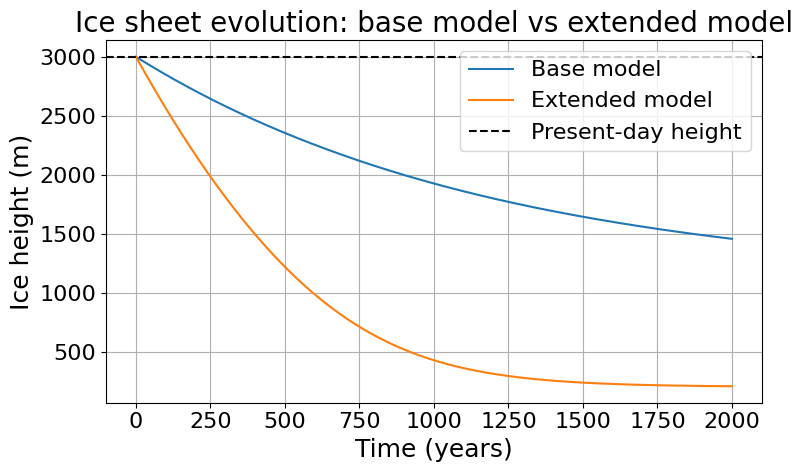

In [11]:
plt.figure(figsize=(8,5))

t1, h1 = simulate("high")
t2, h2 = simulate_extended("high")

plt.plot(t1, h1, label="Base model")
plt.plot(t2, h2, label="Extended model")

plt.axhline(h0, linestyle='--', color='black', label='Present-day height')
plt.xlabel("Time (years)")
plt.ylabel("Ice height (m)")
plt.title("Ice sheet evolution: base model vs extended model")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("ice-sheet.pdf", bbox_inches="tight")
plt.show()

### Sea level response

Sea level rise is estimated from ice height loss via
$$
S(h) = S_{\max} \frac{h_0 - h}{h_0},
$$
where $S_{\max} = 7.5\,\mathrm{m}$ represents complete ice sheet loss.

Under strong warming, the extended model produces a much more rapid increase in sea level compared to the base model, reflecting the impact of nonlinear feedbacks on ice sheet decline.

<Figure size 800x500 with 0 Axes>

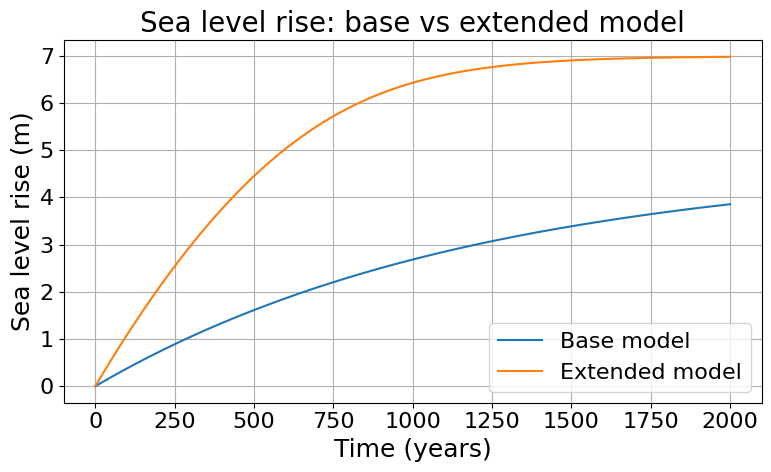

In [12]:
S_max = 7.5  # total possible sea level rise (m)

def sea_level(h):
    return S_max * (h0 - h) / h0
plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))

t1, h1 = simulate("high")
t2, h2 = simulate_extended("high")

plt.plot(t1, sea_level(h1), label="Base model")
plt.plot(t2, sea_level(h2), label="Extended model")

#plt.axhline(7.5, linestyle='--', color='black', label='Full melt (~7.5m)')
plt.xlabel("Time (years)")
plt.ylabel("Sea level rise (m)")
plt.title("Sea level rise: base vs extended model")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("sea-level.pdf", bbox_inches="tight")
plt.show()

### Equilibria in the extended model

We again plot $\frac{dh}{dt}$ against $h$ to identify equilibria under different warming scenarios.

In contrast to the base model, the inclusion of nonlinear melt and flow terms alters the structure of the system, allowing for multiple equilibria and the possibility of abrupt transitions between high and low ice states.

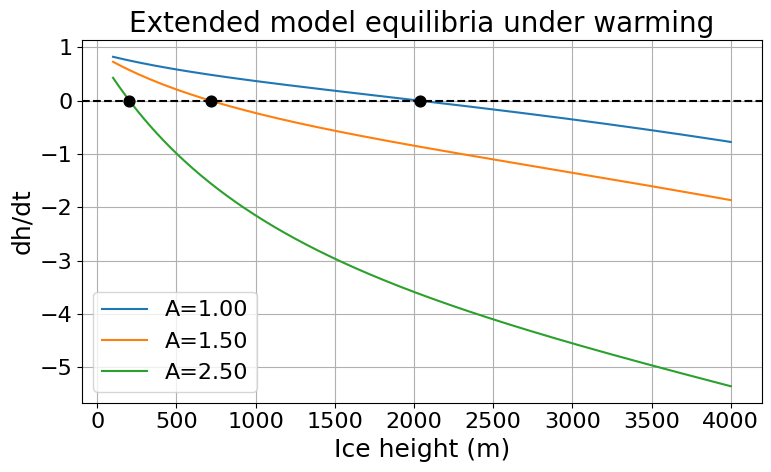

In [13]:
h_vals = np.linspace(100, 4000, 500)

plt.figure(figsize=(8,5))

for A in [A0, A0 + 0.5, A0 + 1.5]:
    dh_vals = P - mu * A**2 * (h_vals / (h_vals + h_c)) - k * h_vals**n

    # Plot curve
    plt.plot(h_vals, dh_vals, label=f"A={A:.2f}")

    # Find equilibrium (where dh/dt ≈ 0)
    idx = np.argmin(np.abs(dh_vals))   # closest to zero
    h_eq = h_vals[idx]

    # Plot dot
    plt.scatter(h_eq, 0, color='black', s=60, zorder=5)

plt.axhline(0, linestyle='--', color='black')
plt.xlabel("Ice height (m)")
plt.ylabel("dh/dt")
plt.title("Extended model equilibria under warming")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("eq-ext.pdf", bbox_inches="tight")
plt.show()